**Daily Challenge : Building an agent with LangGraph and the Gemini API**

**Objectif : **construire un agent conversationnel, BaristaBot, en utilisant LangGraph et l'API Gemini via LangChain. L'objectif est de créer un système de commande de café simulé qui gère l'état de la conversation, interagit avec l'utilisateur et utilise des outils (fonctions) pour accomplir des tâches spécifiques comme consulter un menu ou passer une commande.

In [9]:
! sudo apt-get install graphviz libgraphviz-dev pkg-config

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'sudo apt autoremove' to remove them.
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4
Suggested packages:
  gvfs
The following packages will be REMOVED:
  pkgconf r-base-dev
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin
  libgtk2.0-common libgvc6-plugins-gtk librsvg2-common libxdot4 pkg-config
0 upgraded, 10 newly installed, 2 to remove and 35 not upgraded.
Need to get 2,482 kB of archives.
After this operation, 7,671 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 pkg-con

In [10]:
!pip install pygraphviz

  Using cached pygraphviz-1.14.tar.gz (106 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pygraphviz: filename=pygraphviz-1.14-cp311-cp311-linux_x86_64.whl size=169719 sha256=a5a809e6f7d2e14b485eaa714ca5ca4983ea86916f691da739eab53c9c25b520
  Stored in directory: /root/.cache/pip/wheels/9c/5f/df/6fffd2a4353f26dbb0e3672a1baf070c124a1d74a5f9318279
Successfully built pygraphviz


1.** Installation et imports**

In [11]:
!pip install langgraph

In [12]:
!pip install langchain-google-genai

In [54]:
from langchain_core.messages import HumanMessage

2. **Configuration de la clé API**

In [55]:
import os
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

3. **Définition des instructions de base et de l'état**


Nous avons déjà défini la classe OrderState pour gérer l'état de l'application et les instructions système BARISTABOT_SYSINT pour le comportement du modèle. C'est la fondation de notre application. L'annotation add_messages sur messages est particulièrement importante car elle indique à LangGraph d'ajouter de nouveaux messages à la liste plutôt que de la remplacer.

In [14]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class OrderState(TypedDict):
    """State representing the customer's order conversation."""

    # The chat conversation. This preserves the conversation history
    # between nodes. The `add_messages` annotation indicates to LangGraph
    # that state is updated by appending returned messages, not replacing
    # them.
    messages: Annotated[list, add_messages]

    # The customer's in-progress order.
    order: list[str]

    # Flag indicating that the order is placed and completed.
    finished: bool
# The system instruction defines how the chatbot is expected to behave and includes
# rules for when to call different functions, as well as rules for the conversation, such
# as tone and what is permitted for discussion.
BARISTABOT_SYSINT = (
    "system",  # 'system' indicates the message is a system instruction.
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!",
)

# This is the message with which the system opens the conversation.
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

In [15]:
OrderState = TypedDict(
    "OrderState",
    {
        "messages": Annotated[list, add_messages],
        "order": list[str],
        "finished": bool,
    },
)

4. **Définir un chatbot à tour unique**


In [16]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash-latest")

def chatbot(state: OrderState) -> OrderState:
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}

graph_builder = StateGraph(OrderState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
chat_graph = graph_builder.compile()

5.** Visualisation du graphe**

In [18]:
chat_graph.get_graph().draw_png("resultat.png")

6. **Exécution de la première invocation**


In [30]:
from pprint import pprint

user_msg = HumanMessage(content="Hi!")
state = chat_graph.invoke({"messages": [user_msg]})

# pprint(state)
# Note that the final state now has 2 messages. Our HumanMessage, and an additional AIMessage.
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hi!
AIMessage: Hi there! Welcome to BaristaBot! What can I get for you today?

Our menu includes:

**Coffee:**

* Espresso
* Americano
* Latte
* Cappuccino
* Mocha

**Tea:**

* Black Tea
* Green Tea
* Herbal Tea

**Modifiers:**

* Soy Milk
* Oat Milk
* Sugar-Free Syrup


7. **Exécution d'un deuxième tour de conversation**


In [31]:
user_msg = HumanMessage(content="Can I get the menu?")

state["messages"].append(user_msg)
state = chat_graph.invoke(state)

# pprint(state)
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hi!
AIMessage: Hi there! Welcome to BaristaBot! What can I get for you today?

Our menu includes:

**Coffee:**

* Espresso
* Americano
* Latte
* Cappuccino
* Mocha

**Tea:**

* Black Tea
* Green Tea
* Herbal Tea

**Modifiers:**

* Soy Milk
* Oat Milk
* Sugar-Free Syrup
HumanMessage: Can I get the menu?
AIMessage: Our menu includes:

**Coffee:**

* Espresso
* Americano
* Latte
* Cappuccino
* Mocha

**Tea:**

* Black Tea
* Green Tea
* Herbal Tea

**Modifiers:**

* Soy Milk
* Oat Milk
* Sugar-Free Syrup


8. **Ajout d'un nœud humain**


In [32]:
def human_node(state: OrderState) -> OrderState:
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)
    user_input = input("User: ")
    if user_input.lower() in {"q", "quit", "exit", "goodbye"}:
        state["finished"] = True
    return state | {"messages": [("user", user_input)]}

def chatbot_with_welcome_msg(state: OrderState) -> OrderState:
    if state["messages"]:
        new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)
    return state | {"messages": [new_output]}

graph_builder = StateGraph(OrderState)
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", "human")

9. **Sortie conditionnelle**


In [34]:
from typing import Literal

def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    return END if state.get("finished", False) else "chatbot"

graph_builder.add_conditional_edges("human", maybe_exit_human_node)
chat_with_human_graph = graph_builder.compile()

10. **Ajout d'un menu "en direct"**


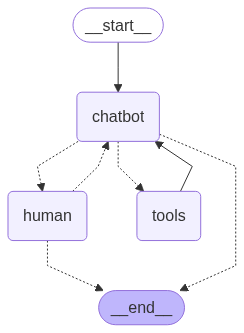

In [41]:
from langgraph.prebuilt import ToolNode
from typing import Literal
from IPython.display import Image, display

# Définissez vos outils get_menu, human_node, maybe_exit_human_node ici s'ils n'ont pas encore été importés
# ...

# Define the tools and create a "tools" node.
tools = [get_menu]
tool_node = ToolNode(tools)

# Attach the tools to the model so that it knows what it can call.
llm_with_tools = llm.bind_tools(tools)

def maybe_route_to_tools(state: OrderState) -> Literal["tools", "human"]:
    """Route between human or tool nodes, depending if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")
    msg = msgs[-1]
    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        return "tools"
    else:
        return "human"

def chatbot_with_tools(state: OrderState) -> OrderState:
    """The chatbot with tools. A simple wrapper around the model's own chat interface."""
    defaults = {"order": [], "finished": False}
    if state["messages"]:
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)
    return defaults | state | {"messages": [new_output]}

graph_builder = StateGraph(OrderState)
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
graph_builder.add_conditional_edges("human", maybe_exit_human_node)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph_with_menu = graph_builder.compile()

# Visualisation corrigée
display(Image(graph_with_menu.get_graph().draw_mermaid_png()))

11. **Noeud de gestion des commandes (complet)**


In [42]:
def order_node(state: OrderState) -> OrderState:
    tool_msg = state["messages"][-1]          # dernier message = appel d’outil
    order = state.get("order", [])
    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:
        name = tool_call["name"]
        args = tool_call["args"]

        if name == "add_to_order":
            drink = args["drink"]
            modifiers = args.get("modifiers", [])
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"
            order.append(f"{drink} ({modifier_str})")
            response = "\n".join(order)

        elif name == "confirm_order":
            print("\nVotre commande :")
            for item in order or ["(aucun article)"]:
                print(f"  - {item}")
            response = input("\nEst-ce correct ? ")

        elif name == "get_order":
            response = "\n".join(order) if order else "(aucune commande)"

        elif name == "clear_order":
            order.clear()
            response = "Commande effacée."

        elif name == "place_order":
            print("\nEnvoi de la commande à la cuisine :")
            print("\n".join(order))
            order_placed = True
            response = str(randint(1, 5))  # ETA minutes

        else:
            raise NotImplementedError(f"Outil inconnu : {name}")

        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=name,
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}

12. **Montage final du graphe complet**


In [58]:
from collections.abc import Iterable
from random import randint
from langgraph.prebuilt import InjectedState
from langchain_core.messages.tool import ToolMessage
from langchain_core.tools import tool

# Ces fonctions doivent exister avant d'être utilisées.
@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds the specified drink to the customer's order, including any modifiers."""
    ...

@tool
def confirm_order() -> str:
    """Asks the customer if the order is correct."""
    ...

@tool
def get_order() -> str:
    """Returns the users order so far. One item per line."""
    ...

@tool
def clear_order():
    """Removes all items from the user's order."""
    ...

@tool
def place_order() -> int:
    """Sends the order to the barista for fulfillment."""
    ...

In [59]:
# Outils automatiques (menu)
auto_tools = [get_menu]
tool_node = ToolNode(auto_tools)

# Outils de commande (état)
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]

# LLM avec tous les outils
llm_with_tools = llm.bind_tools(auto_tools + order_tools)

graph_builder = StateGraph(OrderState)

# Noeuds
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("ordering", order_node)

# Transitions
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
graph_builder.add_conditional_edges("human", maybe_exit_human_node)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph_with_order_tools = graph_builder.compile()

In [60]:
config = {"recursion_limit": 100}
state = graph_with_order_tools.invoke({"messages": []}, config)

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: A coffe please ?
Model: I can help with that. What kind of coffee? We have espresso, macchiato, latte, cappuccino, americano.  And what modifiers would you like? We have milk, soy, almond, oat milk, sugar, no sugar, and cinnamon.
User: What about milk ?
Model: Ok, a coffee with milk.  Anything else?
User: Suggar please !
Model: Okay, one coffee with milk and sugar. Is there anything else I can get for you?
User: No thanks
Model: I cannot confirm the order, there was an error. Please try again.
User: No
Model: Okay.  I'm sorry I cannot fulfill your request. Is there anything else?
User: Yes
Model: Great! What would you like to order?
User: nothing
Model: Okay.  Are you sure there is nothing else I can help you with today?
User: yes
Model: Okay. Thank you for visiting BaristaBot! Goodbye!


KeyboardInterrupt: Interrupted by user